# Segmentación Semántica con Mask2Former

En este cuaderno exploraremos **Mask2Former** (Masked-attention Mask Transformer), una arquitectura unificada introducida en los repositorios de OpenMMLab ([MMDetection](https://github.com/open-mmlab/mmdetection) y MMSegmentation) capaz de resolver tareas de segmentación semántica, de instancias y panóptica estableciendo nuevos estados del arte (SOTA).

Basándonos fuertemente en la estructura y estilo de nuestro cuaderno anterior (`06_cv_segmentacion.ipynb`), implementaremos el entrenamiento de este modelo avanzado. Para facilitar su ejecución interactiva y didáctica sin necesidad de crear el complejo árbol de archivos de configuración propio del *framework* de MMDetection, utilizaremos la integración nativa de los pesos originales de MMDetection provista por **HuggingFace Transformers**, implementando un bucle de entrenamiento puro en `PyTorch` análogo al que usamos para nuestra UNet.

## 1. El Dataset: Kvasir-SEG

De acuerdo a los requisitos, usaremos un dataset real, con más de 800 imágenes para segmentación semántica y de tamaño amigable. Utilizaremos el prestigioso dataset **Kvasir-SEG**, el cual contiene exactamente **1000 imágenes de pólipos gastrointestinales** junto a sus respectivas máscaras de segmentación anotadas por médicos expertos.

Su peso es de tan solo ~46 MB, lo cual nos permite descargarlo y procesarlo en segundos.

In [1]:
# Instalación de los requerimientos base
# pip install wget transformers evaluate opencv-python

In [2]:
import wget
import zipfile
import os

url = 'https://datasets.simula.no/downloads/kvasir-seg.zip'
filename = 'kvasir-seg.zip'

if not os.path.exists(filename):
    print("Descargando el dataset Kvasir-SEG...")
    wget.download(url, filename)

if not os.path.exists('Kvasir-SEG'):
    print("\nExtrayendo archivos...")
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("¡Dataset extraído y listo para usarse!")

Visualicemos algunas muestras del dataset para comprobar su estructura de manera similar a como lo hicimos con las MRIs. Aquí, el pólipo será el objetivo a segmentar (1) contra el tejido sano/fondo (0).

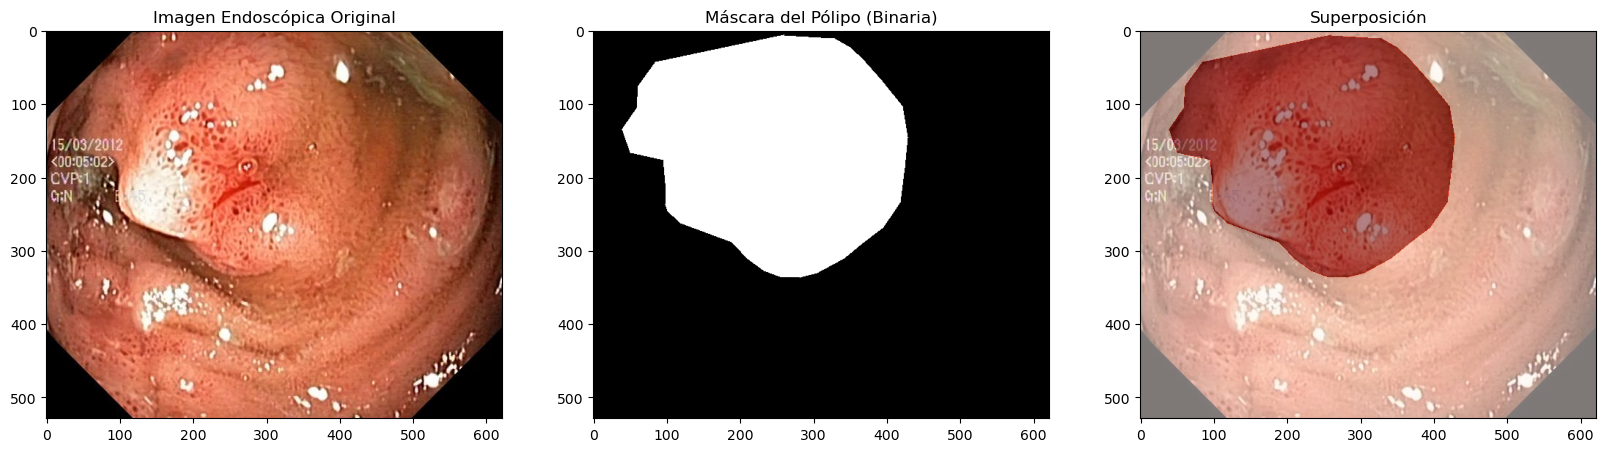

In [3]:
import matplotlib.pyplot as plt
import cv2
import glob
import numpy as np

img_paths = sorted(glob.glob('Kvasir-SEG/images/*.jpg'))
mask_paths = sorted(glob.glob('Kvasir-SEG/masks/*.jpg'))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))
# Cargamos usando OpenCV y convertimos a RGB para Matplotlib
img = cv2.imread(img_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)
_, binary_mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

ax1.imshow(img)
ax1.set_title("Imagen Endoscópica Original")
ax2.imshow(binary_mask, cmap='gray')
ax2.set_title("Máscara del Pólipo (Binaria)")
ax3.imshow(img)
ax3.imshow(binary_mask, alpha=0.5, cmap='Reds')
ax3.set_title("Superposición")
plt.show()

## 2. Preparando el Dataset para Mask2Former

Al igual que en nuestro anterior cuaderno, crearemos una clase `Dataset` de PyTorch. Debido a la naturaleza avanzada del Transformer, utilizaremos su propio procesador de imágenes (`Mask2FormerImageProcessor`), el cual se encarga automáticamente de redimensionar las imágenes, normalizarlas y empaquetar los mapas de segmentación como `mask_labels` (máscaras booleanas por cada clase) y `class_labels` que requiere esta arquitectura.

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Mask2FormerImageProcessor
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Inicializamos el preprocesador oficial (utilizaremos resolución 384x384 por eficiencia)
processor = Mask2FormerImageProcessor(ignore_index=255, reduce_labels=False, do_resize=True, size=(384, 384))

class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Lectura de la imagen en RGB
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Lectura de la máscara y conversión a 0/1
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)
        
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask

def collate_fn(batch):
    # Función necesaria para ensamblar un lote (batch) de tensores
    images, masks = zip(*batch)
    # Genera `pixel_values`, `mask_labels` y `class_labels` estructurados
    inputs = processor(images=list(images), segmentation_maps=list(masks), return_tensors="pt")
    inputs["original_masks"] = list(masks)
    return inputs


d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Definimos las transformaciones para Data Augmentation
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
    A.RandomBrightnessContrast(p=0.2),
])

# Realizamos la división en Entrenamiento (800) y Test (200)
train_dataset = KvasirDataset(img_paths[:800], mask_paths[:800], transform=train_transform)
test_dataset = KvasirDataset(img_paths[800:], mask_paths[800:], transform=None)

dataloader = {
    'train': DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn),
    'test': DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
}

print(f"Datos de Entrenamiento: {len(train_dataset)}")
print(f"Datos de Test: {len(test_dataset)}")

Datos de Entrenamiento: 800
Datos de Test: 200


d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_25448\1333707542.py:6: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),


## 3. Modelo Mask2Former (Transfer Learning)

Vamos a inicializar nuestro modelo con los pesos desarrollados originalmente dentro del entorno de OpenMMLab / MMDetection. 

Aprovecharemos el *Transfer Learning* partiendo de un modelo con *backbone* **Swin-Tiny**, que es una configuración equilibrada y capaz de correr razonablemente bien en recursos estándar. Forzamos que la última capa entienda que nuestro problema solo tiene 2 clases: `num_labels=2` (Fondo y Pólipo).

In [6]:
from transformers import Mask2FormerForUniversalSegmentation

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-tiny-ade-semantic",
    ignore_mismatched_sizes=True, # Resetea la capa final para nuestras 2 clases
    num_labels=2,
    use_safetensors=True
)
model.to(device);


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100%|██████████| 566/566 [00:00<00:00, 3252.19it/s]
[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-ade-semantic
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151, 256]) vs model:torch.Size([3, 256])
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([3])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([151]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty wei

## 4. Bucle de Entrenamiento (Fit)

Exactamente igual que en nuestra práctica anterior, encapsulamos el código de entrenamiento en una función modular `fit`. 

**Nota de arquitectura:** A diferencia del `BCEWithLogitsLoss` que usamos en UNet, Mask2Former maneja internamente la pérdida compleja (una combinación de Cross-Entropy, Focal Loss y Dice Loss por cada máscara segmentada) y nos devuelve este valor directamente en `outputs.loss`.

In [7]:
from tqdm import tqdm
import numpy as np
import copy
from torch.cuda.amp import autocast, GradScaler

def fit(model, dataloaders, epochs=20, lr=5e-5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
    scaler = GradScaler()
    
    hist = {'loss': [], 'iou': [], 'test_loss': [], 'test_iou': []}
    best_iou = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(1, epochs + 1):
        # Train phase
        model.train()
        train_loss, train_iou = [], []
        bar = tqdm(dataloaders['train'])
        
        for batch in bar:
            optimizer.zero_grad()
            
            pixel_values = batch["pixel_values"].to(device)
            mask_labels = [labels.to(device) for labels in batch["mask_labels"]]
            class_labels = [labels.to(device) for labels in batch["class_labels"]]
            
            with autocast():
                outputs = model(
                    pixel_values=pixel_values,
                    mask_labels=mask_labels,
                    class_labels=class_labels
                )
                loss = outputs.loss
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss.append(loss.item())
            
            target_sizes = [m.shape for m in batch["original_masks"]]
            pred_masks = processor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)
            
            ious = []
            for pred_m, true_m in zip(pred_masks, batch["original_masks"]):
                pred_m = pred_m.cpu().numpy()
                intersection = np.logical_and(pred_m == 1, true_m == 1).sum()
                union = np.logical_or(pred_m == 1, true_m == 1).sum()
                ious.append(intersection / max(union, 1))
            
            train_iou.extend(ious)
            bar.set_description(f"loss {np.mean(train_loss):.5f} iou {np.mean(train_iou):.5f}")
            
        hist['loss'].append(np.mean(train_loss))
        hist['iou'].append(np.mean(train_iou))
        
        # Test phase
        model.eval()
        test_loss, test_iou = [], []
        bar = tqdm(dataloaders['test'])
        
        with torch.no_grad():
            for batch in bar:
                pixel_values = batch["pixel_values"].to(device)
                mask_labels = [labels.to(device) for labels in batch["mask_labels"]]
                class_labels = [labels.to(device) for labels in batch["class_labels"]]
                
                with autocast():
                    outputs = model(
                        pixel_values=pixel_values,
                        mask_labels=mask_labels,
                        class_labels=class_labels
                    )
                    loss = outputs.loss
                
                test_loss.append(loss.item())
                
                target_sizes = [m.shape for m in batch["original_masks"]]
                pred_masks = processor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)
                
                ious = []
                for pred_m, true_m in zip(pred_masks, batch["original_masks"]):
                    pred_m = pred_m.cpu().numpy()
                    intersection = np.logical_and(pred_m == 1, true_m == 1).sum()
                    union = np.logical_or(pred_m == 1, true_m == 1).sum()
                    ious.append(intersection / max(union, 1))
                
                test_iou.extend(ious)
                bar.set_description(f"test_loss {np.mean(test_loss):.5f} test_iou {np.mean(test_iou):.5f}")
                
        hist['test_loss'].append(np.mean(test_loss))
        hist['test_iou'].append(np.mean(test_iou))
        
        epoch_test_iou = np.mean(test_iou)
        print(f"\nEpoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} iou {np.mean(train_iou):.5f} test_loss {np.mean(test_loss):.5f} test_iou {epoch_test_iou:.5f}")
        
        if epoch_test_iou > best_iou:
            best_iou = epoch_test_iou
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"🌟 Nuevo mejor modelo encontrado! (IoU: {best_iou:.5f})")
            
        scheduler.step(epoch_test_iou)
        
    print(f"\nEntrenamiento completado. Mejor Test IoU: {best_iou:.5f}")
    model.load_state_dict(best_model_wts)
    return hist


In [8]:
# Entrenamos el modelo y guardamos el historial
hist = fit(model, dataloader, epochs=20)


d:\quinto_semestre\anaconda\envs\conda_GPU\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_25448\4193921105.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/200 [00:00<?, ?it/s]C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_25448\4193921105.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\VICTUS hp\AppData\Local\Temp\ipykernel_25448\4193921105.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
test_loss 17.12250 test_iou 0.74558: 100%|██████████| 100/


Epoch 1/20 loss 22.23274 iou 0.68370 test_loss 17.12250 test_iou 0.74558
🌟 Nuevo mejor modelo encontrado! (IoU: 0.74558)


test_loss 16.60967 test_iou 0.80643: 100%|██████████| 100/100 [00:32<00:00,  3.11it/s]



Epoch 2/20 loss 15.90171 iou 0.80979 test_loss 16.60967 test_iou 0.80643
🌟 Nuevo mejor modelo encontrado! (IoU: 0.80643)


test_loss 14.83676 test_iou 0.83752: 100%|██████████| 100/100 [00:28<00:00,  3.55it/s]


...


Epoch 18/20 loss 7.37008 iou 0.91862 test_loss 12.94608 test_iou 0.86157


test_loss 13.25625 test_iou 0.85687: 100%|██████████| 100/100 [00:31<00:00,  3.18it/s]



Epoch 19/20 loss 6.96554 iou 0.92478 test_loss 13.25625 test_iou 0.85687


test_loss 13.77940 test_iou 0.85842: 100%|██████████| 100/100 [00:28<00:00,  3.48it/s]


Epoch 20/20 loss 6.90171 iou 0.92362 test_loss 13.77940 test_iou 0.85842

Entrenamiento completado. Mejor Test IoU: 0.86454


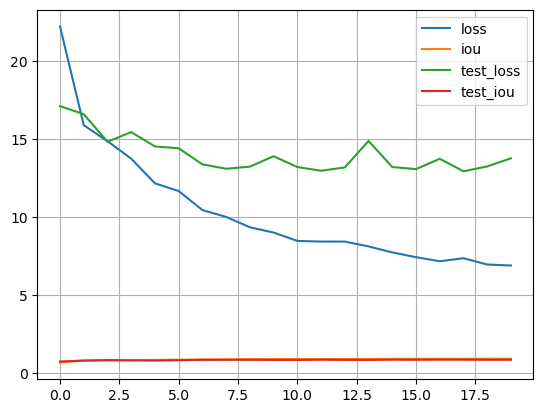

In [9]:
import pandas as pd
df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()

## 5. Inferencia y Visualización de Resultados

Una vez el modelo ha realizado algunas pasadas por los datos, podemos alimentar una imagen del conjunto de Test y visualizar la salida post-procesada.

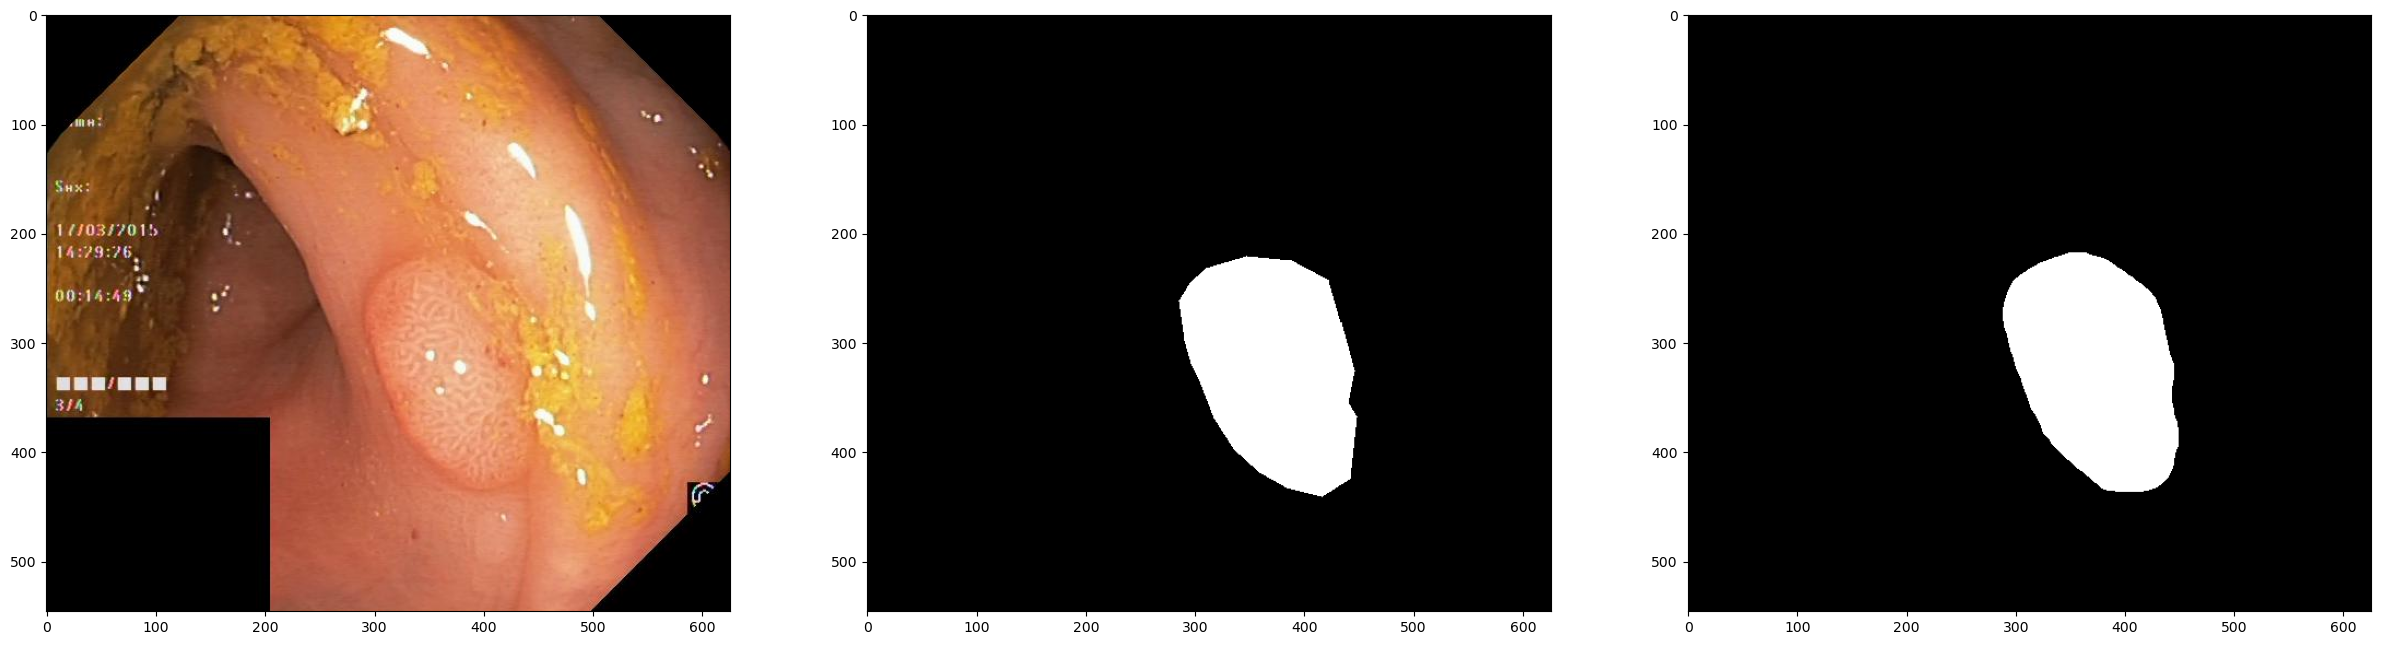

In [10]:
import random

model.eval()
with torch.no_grad():
    # Seleccionamos un índice aleatorio del test_dataset
    ix = random.randint(0, len(test_dataset)-1)
    original_image, true_mask = test_dataset[ix]
    
    # Transformamos mediante el procesador y mandamos a GPU
    inputs = processor(images=original_image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    
    # Pasada a través del modelo
    outputs = model(pixel_values=pixel_values)
    
    # Delegamos al procesador el redimensionamiento del mapa devuelto para igualar la imagen original
    pred_masks = processor.post_process_semantic_segmentation(outputs, target_sizes=[original_image.shape[:2]])
    pred_mask = pred_masks[0].cpu().numpy()

# Renderizamos los resultados
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))
ax1.imshow(original_image)
ax2.imshow(true_mask, cmap='gray')
ax3.imshow(pred_mask, cmap='gray')
plt.show()
